In [114]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from h3 import *
from shapely.geometry import Point
from shapely.geometry import LineString, Point
import numpy as np

# Configuration

In [116]:
tolerance  = 2
street_length = 20

# Generate the arbitrary pass

## Arbitrary survey

In [117]:
import pandas as pd
import geopandas as gpd

# Create a DataFrame with the pass name and geometries
survey_gdf = gpd.GeoDataFrame({
    'Order': [1,2,3,4,5],
    'geometry': [
        LineString([(-800, -800),(0, 0),(-800, 800)]),
        LineString([(800, 800),(0, 700),(-800, 800)]),
        LineString([(800, 800),(0,0 ),(800, -800)]),
        LineString([(775, 775),(0, 675)]),
        LineString([(835, 835),(0, 735)])
    ]
}, geometry='geometry', crs='EPSG:3857')

<Axes: >

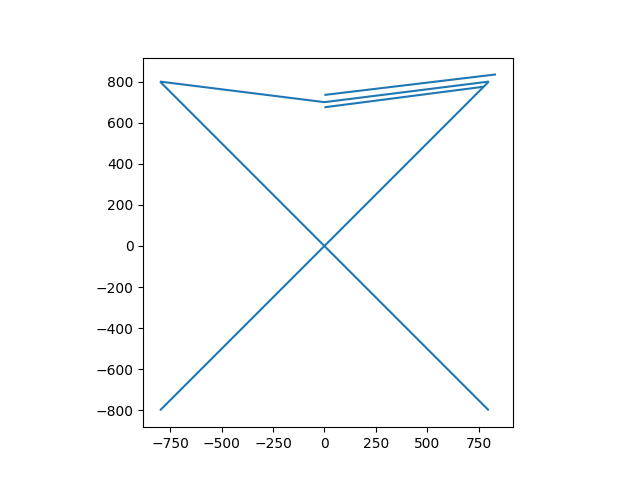

In [118]:
survey_gdf.plot()

# Generate the grid

In [119]:
# Segment the survey into single lines
from shapely.geometry import LineString

# Function to segment a LineString into its line segments as new LineStrings
def segment_lines(geometry):
    if geometry.geom_type == 'LineString':
        coords = list(geometry.coords)
        segments = [LineString([coords[i], coords[i+1]]) for i in range(len(coords)-1)]
        return segments
    else:
        return []

# Explode all lines in survey_gdf into individual segments
segmented_rows = []
for idx, row in survey_gdf.iterrows():
    segments = segment_lines(row.geometry)
    for seg in segments:
        segmented_rows.append({
            'Order': row['Order'],
            'geometry': seg
        })

segmented_survey_gdf = gpd.GeoDataFrame(segmented_rows, geometry='geometry', crs=survey_gdf.crs).reset_index(drop=True).rename_axis("sub_index").reset_index()

# Now segmented_survey_gdf contains each survey path as individual line segments

In [120]:
min_x = -1000
max_x = 1000
min_y = -1000
max_y = 1000
dx = 1
# Create the set of grid lines
x_coords = np.arange(min_x, max_x, 25)
vertical_lines = [LineString([(x, min_y), (x, max_y)]) for x in x_coords]
geometry_z = [Point(x, max_y) for x in x_coords]
grid_lines_gdf = gpd.GeoDataFrame(vertical_lines, columns=['geometry'], crs='EPSG:3857')
grid_lines_gdf = grid_lines_gdf.reset_index().rename(columns={'index': 'line_index'})
grid_lines_gdf['geometry_z'] = geometry_z
grid_lines_gdf['dx'] = grid_lines_gdf.apply(lambda row: row.geometry.parallel_offset(dx, side='right'), axis=1)

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


In [121]:
intersection_gdf = gpd.overlay(grid_lines_gdf, segmented_survey_gdf, how='intersection', keep_geom_type=False)
intersection_gdf.rename(columns={'geometry': 'geometry_x'}, inplace=True)
# The overlay operation needs both GeoDataFrames to have an active geometry column. 
# grid_lines_gdf[['dx']] does not have its geometry column set, so let's set it.
grid_lines_dx = grid_lines_gdf.copy()
grid_lines_dx = grid_lines_dx.set_geometry('dx')
grid_lines_dx.crs = grid_lines_gdf.crs
# Now perform the overlay
intersection_gdf_dx = gpd.overlay(grid_lines_dx, segmented_survey_gdf,  how='intersection', keep_geom_type=False)
intersection_gdf_dx.drop(columns=['geometry_z'], inplace=True)

In [122]:
intersection_gdf = pd.merge(intersection_gdf, intersection_gdf_dx, how='outer', on=['line_index', 'sub_index','Order'])
intersection_gdf.rename(columns={'geometry': 'geometry_y'}, inplace=True)

In [123]:
intersection_gdf

,line_index,geometry_z,dx,sub_index,Order,geometry_x,geometry_y
0,8,POINT (-800 1000),"LINESTRING (-799.000 1000.000, -799.000 -1000....",0,1,POINT (-800.000 -800.000),POINT (-799.000 -799.000)
1,9,POINT (-775 1000),"LINESTRING (-774.000 1000.000, -774.000 -1000....",0,1,POINT (-775.000 -775.000),POINT (-774.000 -774.000)
2,10,POINT (-750 1000),"LINESTRING (-749.000 1000.000, -749.000 -1000....",0,1,POINT (-750.000 -750.000),POINT (-749.000 -749.000)
3,11,POINT (-725 1000),"LINESTRING (-724.000 1000.000, -724.000 -1000....",0,1,POINT (-725.000 -725.000),POINT (-724.000 -724.000)
4,12,POINT (-700 1000),"LINESTRING (-699.000 1000.000, -699.000 -1000....",0,1,POINT (-700.000 -700.000),POINT (-699.000 -699.000)
...,...,...,...,...,...,...,...
259,69,POINT (725 1000),"LINESTRING (726.000 1000.000, 726.000 -1000.000)",7,5,POINT (725.000 821.826),POINT (726.000 821.946)
260,70,POINT (750 1000),"LINESTRING (751.000 1000.000, 751.000 -1000.000)",7,5,POINT (750.000 824.820),POINT (751.000 824.940)
261,71,POINT (775 1000),"LINESTRING (776.000 1000.000, 776.000 -1000.000)",7,5,POINT (775.000 827.814),POINT (776.000 827.934)
262,72,POINT (800 1000),"LINESTRING (801.000 1000.000, 801.000 -1000.000)",7,5,POINT (800.000 830.808),POINT (801.000 830.928)


In [124]:
# Take the unit vector from p1 (Point) to p2 (Point)
def unit_vector_between_points(p1, p2):
    try:
        if p1 is None or p2 is None:
            return np.array([np.nan, np.nan])
        x0, y0 = p1.x, p1.y
        x1, y1 = p2.x, p2.y
        dx = x1 - x0
        dy = y1 - y0
        norm = np.sqrt(dx**2 + dy**2)
        if norm == 0:
            return np.array([np.nan, np.nan])
        return np.array([dx/norm, dy/norm])
    except Exception:
        return np.array([np.nan, np.nan])

# Assuming you want to calculate unit vectors between two columns of points in intersection_gdf,
# replace 'geometry_x' and 'geometry_y' below with the actual relevant column names as needed.  

intersection_gdf['u1'] = intersection_gdf.apply(lambda row: unit_vector_between_points(row['geometry_x'], row['geometry_z']), axis=1)
intersection_gdf['u2'] = intersection_gdf.apply(lambda row: unit_vector_between_points(row['geometry_x'], row['geometry_y']), axis=1)

In [125]:
def angle_between_vectors(v1, v2):
    # v1 and v2 should be numpy arrays with 2 elements
    try:
        if np.any(np.isnan(v1)) or np.any(np.isnan(v2)):
            return np.nan
        dot_product = np.dot(v1, v2)
        norm1 = np.linalg.norm(v1)
        norm2 = np.linalg.norm(v2)
        if norm1 == 0 or norm2 == 0:
            return np.nan
        # Clip for numerical stability
        cos_theta = np.clip(dot_product / (norm1 * norm2), -1.0, 1.0)
        angle_rad = np.arccos(cos_theta)
        return np.degrees(angle_rad)
    except Exception:
        return np.nan

intersection_gdf['angle_u1_u2'] = intersection_gdf.apply(lambda row: angle_between_vectors(row['u1'], row['u2']), axis=1)

In [126]:
intersection_gdf['u2']

0      [0.7071067811865475, 0.7071067811865475]
1      [0.7071067811865475, 0.7071067811865475]
2      [0.7071067811865475, 0.7071067811865475]
3      [0.7071067811865475, 0.7071067811865475]
4      [0.7071067811865475, 0.7071067811865475]
                         ...                   
259    [0.9929049442707539, 0.1189107717689654]
260    [0.9929049442707539, 0.1189107717689654]
261    [0.9929049442707539, 0.1189107717689654]
262    [0.9929049442707539, 0.1189107717689654]
263    [0.9929049442707539, 0.1189107717689654]
Name: u2, Length: 264, dtype: object

In [127]:
intersection_gdf['inv'] = intersection_gdf['u2'].apply(lambda arr: arr[::-1] if isinstance(arr, (list, np.ndarray)) else arr)
intersection_gdf['inv'] = intersection_gdf['inv'].apply(
    lambda arr: [-arr[0], arr[1]] if isinstance(arr, (list, np.ndarray)) and len(arr) == 2 and not np.isnan(arr[0]) and not np.isnan(arr[1]) else arr
)


In [128]:
from shapely.geometry import Point, LineString

def point_from_vec(base_point, vec):
    # base_point: shapely Point
    # vec: [dx, dy]
    if not isinstance(base_point, Point):
        return None
    if not isinstance(vec, (list, np.ndarray)) or len(vec) != 2:
        return None
    if np.isnan(vec[0]) or np.isnan(vec[1]):
        return None
    return Point(base_point.x + vec[0], base_point.y + vec[1])

# Create the new point by adding inv vector to geometry_x, then create line to geometry_x
intersection_gdf['inv_point'] = intersection_gdf.apply(
    lambda row: point_from_vec(row['geometry_x'], row['inv']), axis=1
)
intersection_gdf['inv_line'] = intersection_gdf.apply(
    lambda row: LineString([row['geometry_x'], row['inv_point']]) 
        if isinstance(row['geometry_x'], Point) and isinstance(row['inv_point'], Point)
        else None,
    axis=1
)
from shapely.geometry import LineString

def extrapolate_line_shapely(line, distance=10):
    """
    Extrapolate the line by 'distance' units beyond its end based on direction.
    Only works for LineStrings with exactly 2 points.
    """
    if not isinstance(line, LineString) or len(line.coords) != 2:
        return None
    x0, y0 = line.coords[0]
    x1, y1 = line.coords[1]
    dx = x1 - x0
    dy = y1 - y0
    length = np.hypot(dx, dy)
    if length == 0:
        return None
    # Normalize direction
    dx_norm = dx / length
    dy_norm = dy / length
    # Extrapolate beyond (x1, y1)
    x2 = x1 + dx_norm * distance
    y2 = y1 + dy_norm * distance
    # Create new LineString: start, end, extrapolated point
    return LineString([(x0, y0), (x1, y1), (x2, y2)])

intersection_gdf['inv_line_extrapolated'] = intersection_gdf['inv_line'].apply(
    lambda line: extrapolate_line_shapely(line, distance=30)
)

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


In [129]:
intersection_gdf

,line_index,geometry_z,dx,sub_index,Order,geometry_x,geometry_y,u1,u2,angle_u1_u2,inv,inv_point,inv_line,inv_line_extrapolated
0,8,POINT (-800 1000),"LINESTRING (-799.000 1000.000, -799.000 -1000....",0,1,POINT (-800.000 -800.000),POINT (-799.000 -799.000),"[0.0, 1.0]","[0.7071067811865475, 0.7071067811865475]",45.000000,"[-0.7071067811865475, 0.7071067811865475]",POINT (-800.707 -799.293),"LINESTRING (-800.000 -800.000, -800.707 -799.293)","LINESTRING (-800.000 -800.000, -800.707 -799.2..."
1,9,POINT (-775 1000),"LINESTRING (-774.000 1000.000, -774.000 -1000....",0,1,POINT (-775.000 -775.000),POINT (-774.000 -774.000),"[0.0, 1.0]","[0.7071067811865475, 0.7071067811865475]",45.000000,"[-0.7071067811865475, 0.7071067811865475]",POINT (-775.707 -774.293),"LINESTRING (-775.000 -775.000, -775.707 -774.293)","LINESTRING (-775.000 -775.000, -775.707 -774.2..."
2,10,POINT (-750 1000),"LINESTRING (-749.000 1000.000, -749.000 -1000....",0,1,POINT (-750.000 -750.000),POINT (-749.000 -749.000),"[0.0, 1.0]","[0.7071067811865475, 0.7071067811865475]",45.000000,"[-0.7071067811865475, 0.7071067811865475]",POINT (-750.707 -749.293),"LINESTRING (-750.000 -750.000, -750.707 -749.293)","LINESTRING (-750.000 -750.000, -750.707 -749.2..."
3,11,POINT (-725 1000),"LINESTRING (-724.000 1000.000, -724.000 -1000....",0,1,POINT (-725.000 -725.000),POINT (-724.000 -724.000),"[0.0, 1.0]","[0.7071067811865475, 0.7071067811865475]",45.000000,"[-0.7071067811865475, 0.7071067811865475]",POINT (-725.707 -724.293),"LINESTRING (-725.000 -725.000, -725.707 -724.293)","LINESTRING (-725.000 -725.000, -725.707 -724.2..."
4,12,POINT (-700 1000),"LINESTRING (-699.000 1000.000, -699.000 -1000....",0,1,POINT (-700.000 -700.000),POINT (-699.000 -699.000),"[0.0, 1.0]","[0.7071067811865475, 0.7071067811865475]",45.000000,"[-0.7071067811865475, 0.7071067811865475]",POINT (-700.707 -699.293),"LINESTRING (-700.000 -700.000, -700.707 -699.293)","LINESTRING (-700.000 -700.000, -700.707 -699.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,69,POINT (725 1000),"LINESTRING (726.000 1000.000, 726.000 -1000.000)",7,5,POINT (725.000 821.826),POINT (726.000 821.946),"[0.0, 1.0]","[0.9929049442707539, 0.1189107717689654]",83.170756,"[-0.1189107717689654, 0.9929049442707539]",POINT (724.881 822.819),"LINESTRING (725.000 821.826, 724.881 822.819)","LINESTRING (725.000 821.826, 724.881 822.819, ..."
260,70,POINT (750 1000),"LINESTRING (751.000 1000.000, 751.000 -1000.000)",7,5,POINT (750.000 824.820),POINT (751.000 824.940),"[0.0, 1.0]","[0.9929049442707539, 0.1189107717689654]",83.170756,"[-0.1189107717689654, 0.9929049442707539]",POINT (749.881 825.813),"LINESTRING (750.000 824.820, 749.881 825.813)","LINESTRING (750.000 824.820, 749.881 825.813, ..."
261,71,POINT (775 1000),"LINESTRING (776.000 1000.000, 776.000 -1000.000)",7,5,POINT (775.000 827.814),POINT (776.000 827.934),"[0.0, 1.0]","[0.9929049442707539, 0.1189107717689654]",83.170756,"[-0.1189107717689654, 0.9929049442707539]",POINT (774.881 828.807),"LINESTRING (775.000 827.814, 774.881 828.807)","LINESTRING (775.000 827.814, 774.881 828.807, ..."
262,72,POINT (800 1000),"LINESTRING (801.000 1000.000, 801.000 -1000.000)",7,5,POINT (800.000 830.808),POINT (801.000 830.928),"[0.0, 1.0]","[0.9929049442707539, 0.1189107717689654]",83.170756,"[-0.1189107717689654, 0.9929049442707539]",POINT (799.881 831.801),"LINESTRING (800.000 830.808, 799.881 831.801)","LINESTRING (800.000 830.808, 799.881 831.801, ..."


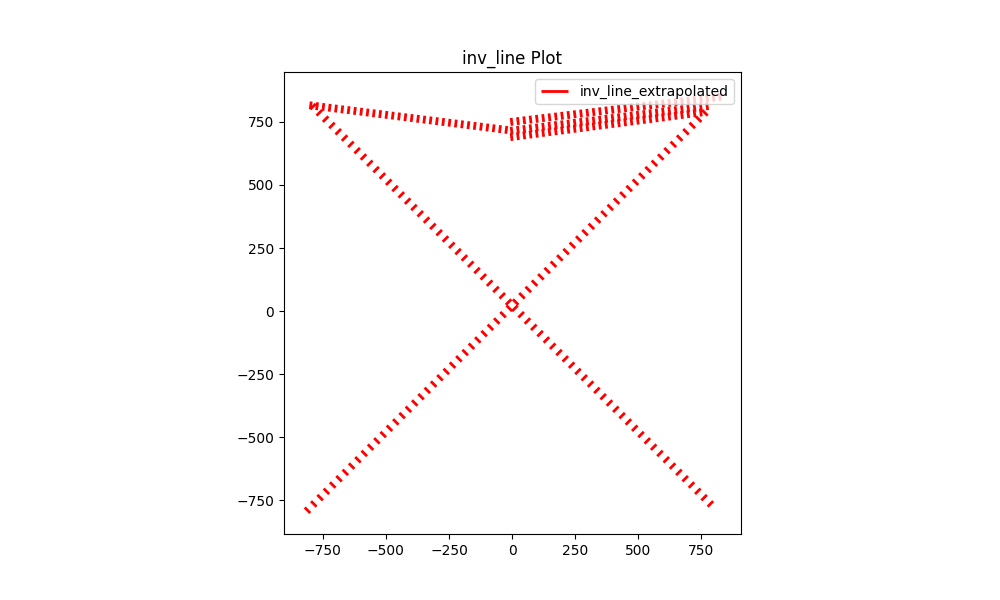

In [130]:
import matplotlib.pyplot as plt

# Plot the 'inv_line' geometries
fig, ax = plt.subplots(figsize=(10, 6))
intersection_gdf.set_geometry('inv_line_extrapolated').plot(ax=ax, color='red', linewidth=2, label='inv_line_extrapolated')
ax.set_title('inv_line Plot')
ax.legend()
plt.show()

<Axes: >

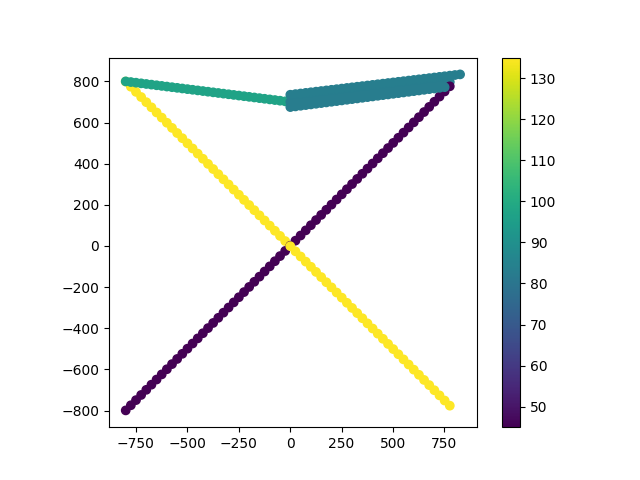

In [131]:
import matplotlib.pyplot as plt

# Plot the angle_u1_u2 column as a line plot
intersection_gdf.set_geometry('geometry_y', inplace=True)
intersection_gdf.plot(column='angle_u1_u2', cmap='viridis', legend=True)